In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy as sp
import curveball # Note; run in separate environment (curveball) with scipy < 1.10
import time
import scipy.stats as stats
from pathlib import Path




# Load cultivation data
- This dataframe is created in the plot_results.ipynb notebook
- These OD values are corrected

In [4]:
folder = Path('../../data/4_growth_phenotyping/')

df = pd.read_csv(folder / "od_all_species_long.csv", index_col=0)

In [5]:
binary_growth = pd.read_csv(folder/'growth_no_growth.csv', index_col = 0)

In [6]:
binary_growth_dict = binary_growth.to_dict()

## Load background data


In [11]:
df.replace({'Carbon source': 'No cs'}, 'No CS', inplace=True)

In [34]:
species = ['At', 'Ct', 'Ml', 'Oa']
cs_list = sorted(df['Carbon source'].unique(), key=lambda x: (x == "No CS", x))
df['Time'] = df['Hours'] # Needed for curveball

# Fit growth curves
For this I use the curveball package https://curveball.yoavram.com/


In [13]:
def store_results(s, cs, model_fits = None, idx = None):
    res = {}
    # res['folder'] = os.path.dirname(filepath)
    # res['filename'] = os.path.splitext(os.path.basename(fn))[0]
    res['Species'] = s
    res['Carbon source'] = cs
    
   
    curr_idx = idx
    if model_fits:
        mu = np.nan
        while np.isnan(mu):
            print(s, cs, idx)
            fit = model_fits[idx]
            res['model'] = fit.model.name
            res['RSS'] = fit.chisqr
            res['RMSD'] = np.sqrt(res['RSS'] / fit.ndata)
            # res['NRMSD'] = res['RMSD'] / (strain_df.OD.max() - strain_df.OD.min())
            # res['CV(RMSD)'] = res['RMSD'] / (strain_df.OD.mean())
            res['bic'] = fit.bic
            res['aic'] = fit.aic
            res['weighted_bic'] = fit.weighted_bic
            res['weighted_aic'] = fit.weighted_aic
            params = fit.params
            res['y0'] = params['y0'].value
            res['K'] = params['K'].value
            res['r'] = params['r'].value
            res['nu'] = params['nu'].value if 'nu' in params else 1
            res['q0'] = params['q0'].value if 'q0' in params else 0
            res['v'] = params['v'].value if 'v' in params else 0
            res['has_lag'] = curveball.models.has_lag(model_fits)
            res['has_nu'] = curveball.models.has_nu(model_fits)
            res['max_growth_rate'] = curveball.models.find_max_growth(fit)[-1]
            res['min_doubling_time'] = curveball.models.find_min_doubling_time(fit)
            res['lag'] = curveball.models.find_lag(fit)
            mu = res['max_growth_rate']
            if idx == curr_idx:
                idx = 0
                curr_idx = np.inf
            else:
                idx += 1
        
            if idx >= len(model_fits):
                print('No growth rate found')
                break
    return res

At Acetate 68.0
At Acetate 0
At Adenosine 76.0
At Adenosine 0
At Cysteine 32.0
At Cysteine 0
At D-arabinose 52.0
At D-arabinose 0
At D-glucose 44.0
At D-glucose 0
At D-xylose 51.0
At D-xylose 0
At Formate 76.0
At Formate 0
At Fumarate 25.0
At Fumarate 0
At Glutarate 74.0
At Glutarate 0
At Glycerol 59.0
At Glycerol 0
At Inosine 76.0
At Inosine 0
At L-alanine 62.0
At L-alanine 0
At L-arginine 51.0
At L-arginine 0
At L-aspartate 29.0
At L-aspartate 0
At L-glutamate 35.0
At L-glutamate 0
At L-glutamine 36.0
At L-glutamine 0
At L-histidine 45.0
At L-histidine 0
At L-lactate 37.0
At L-lactate 0
At L-leucine 76.0
At L-leucine 0
At Malate 42.0
At Malate 0
At Mannitol 32.0
At Mannitol 0
At Mannose 40.0
At Mannose 0
At Myo-inositol 36.0
At Myo-inositol 0
At Orotate 42.0
At Orotate 0
At Proline 47.0
At Proline 0
At Pyruvate 33.0
At Pyruvate 0
At Ribose 58.0
At Ribose 0
At Sucrose 30.0
At Sucrose 0
At Uridine 76.0
At Uridine 0
Ct Acetate 27.0
Ct Acetate 0
Ct Citrate 73.0
Ct Citrate 0
Ct Cysteine 1

/Users/snorre/miniconda3/envs/curveball/lib/python3.11/site-packages/curveball/models.py:640: UserWarning: All values are below K/e
  warn("All values are below K/e")


Ml L-histidine 0
Ml L-isoleucine 73.0
Ml L-isoleucine 0
Ml L-isoleucine 0
Ml L-isoleucine 1
Ml L-lactate 72.0


/Users/snorre/miniconda3/envs/curveball/lib/python3.11/site-packages/curveball/models.py:640: UserWarning: All values are below K/e
  warn("All values are below K/e")


Ml L-lactate 0
Ml L-leucine 73.0
Ml L-leucine 0
Ml Malate 72.0
Ml Malate 0
Ml Mannitol 52.0
Ml Mannitol 0
Ml Mannose 51.0
Ml Mannose 0
Ml Myo-inositol 73.0
Ml Myo-inositol 0
Ml Phenylalanine 73.0
Ml Phenylalanine 0
Ml Proline 73.0
Ml Proline 0
Ml Pyruvate 90.0
Ml Pyruvate 0
Ml Ribose 73.0
Ml Ribose 0
Ml Sucrose 51.0
Ml Sucrose 0
Ml Uridine 73.0
Ml Uridine 0
Oa Acetate 43.0
Oa Acetate 0
Oa Citrate 86.0
Oa Citrate 0
Oa Cysteine 59.0
Oa Cysteine 0
Oa D-arabinose 66.0
Oa D-arabinose 0
Oa D-glucose 40.0
Oa D-glucose 0
Oa D-xylose 47.0
Oa D-xylose 0
Oa Fumarate 24.0
Oa Fumarate 0
Oa Glutarate 50.0
Oa Glutarate 0
Oa Glycine 42.0
Oa Glycine 0
Oa Inosine 76.0
Oa Inosine 0
Oa Inosine 0
Oa Inosine 1
Oa Inosine 2
Oa L-alanine 43.0


/Users/snorre/miniconda3/envs/curveball/lib/python3.11/site-packages/curveball/models.py:640: UserWarning: All values are below K/e
  warn("All values are below K/e")


Oa L-alanine 0
Oa L-arginine 60.0
Oa L-arginine 0
Oa L-aspartate 53.0
Oa L-aspartate 0
Oa L-glutamate 43.0
Oa L-glutamate 0
Oa L-glutamine 75.0
Oa L-glutamine 0
Oa L-histidine 43.0
Oa L-histidine 0
Oa L-isoleucine 76.0
Oa L-isoleucine 0
Oa L-lactate 35.0
Oa L-lactate 0
Oa L-leucine 76.0
Oa L-leucine 0
Oa Malate 24.0
Oa Malate 0
Oa Mannitol 75.0
Oa Mannitol 0
Oa Mannose 53.0
Oa Mannose 0
Oa Myo-inositol 45.0
Oa Myo-inositol 0
Oa Proline 53.0
Oa Proline 0
Oa Pyruvate 39.0
Oa Pyruvate 0
Oa Ribose 66.0
Oa Ribose 0
Oa Sucrose 36.0
Oa Sucrose 0


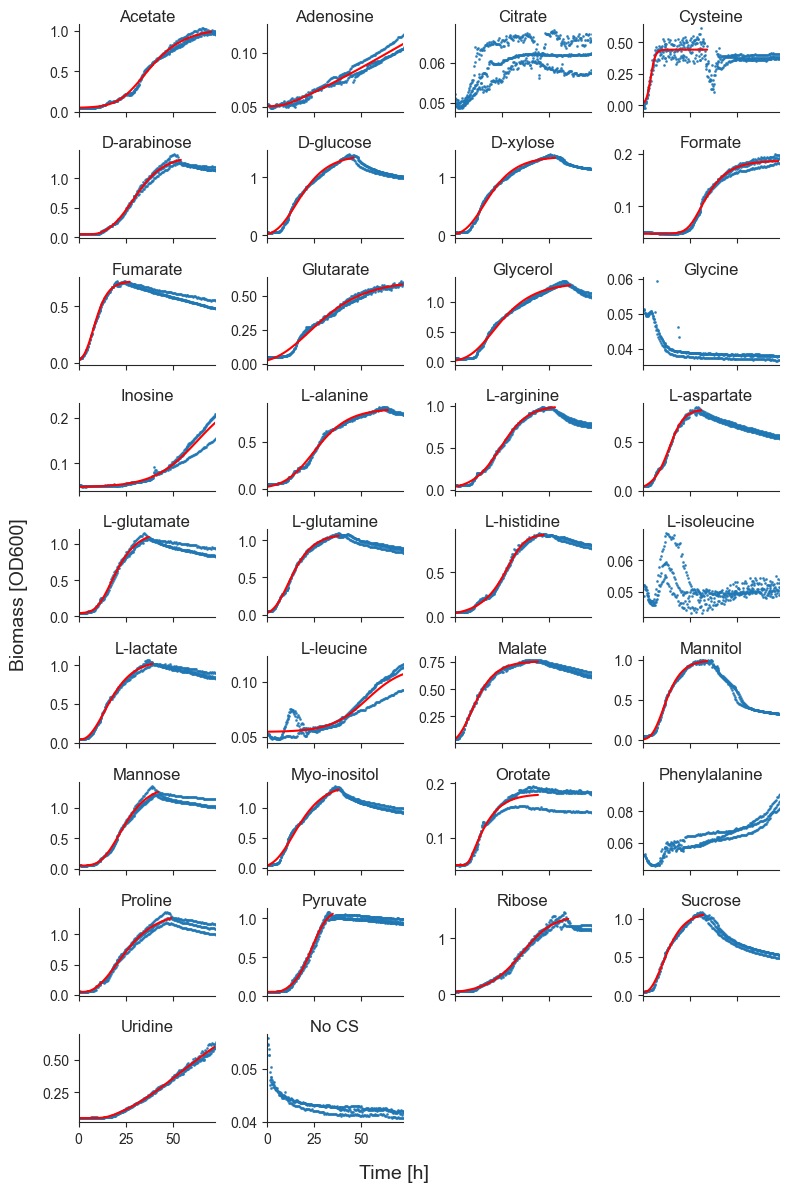

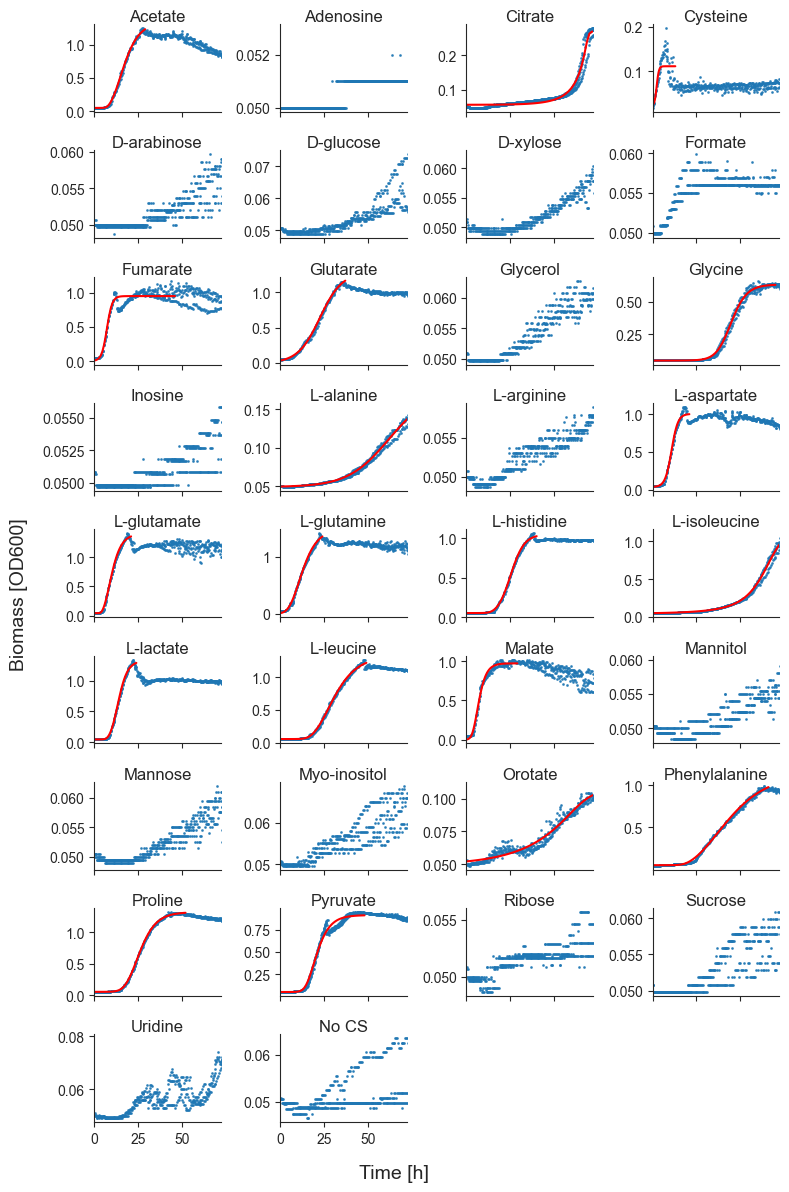

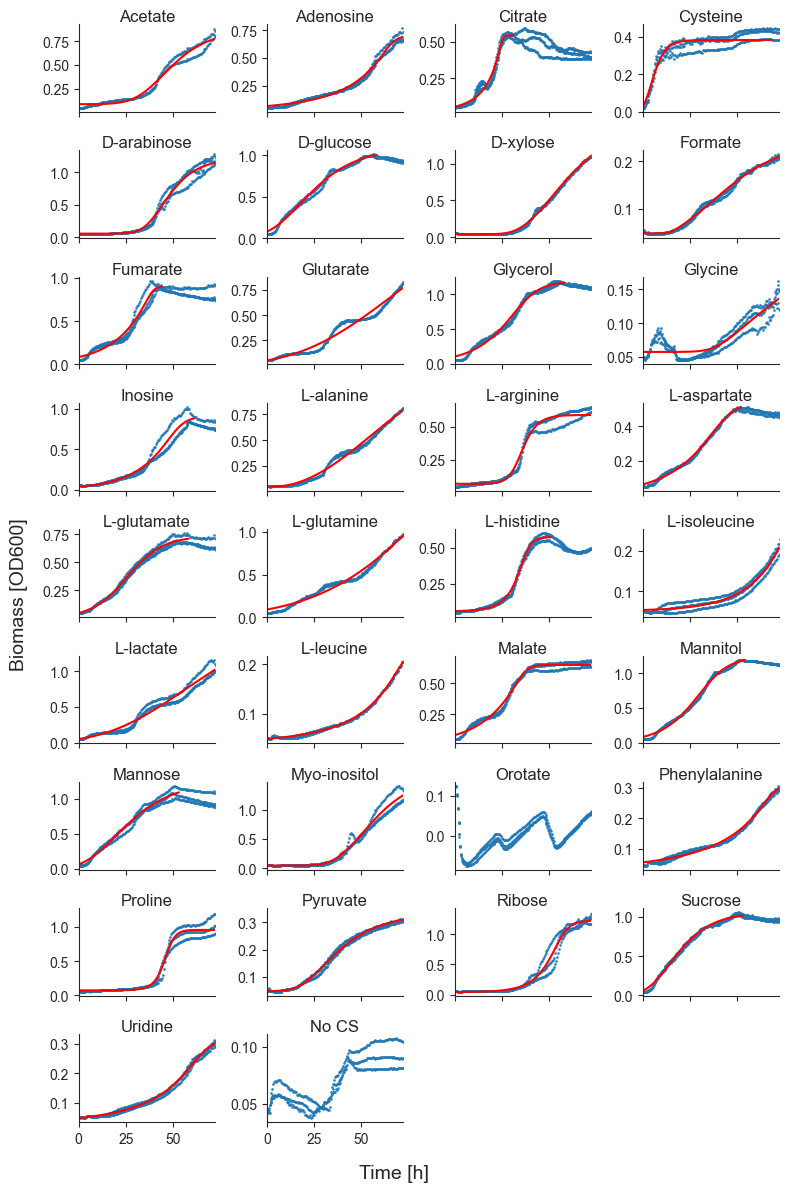

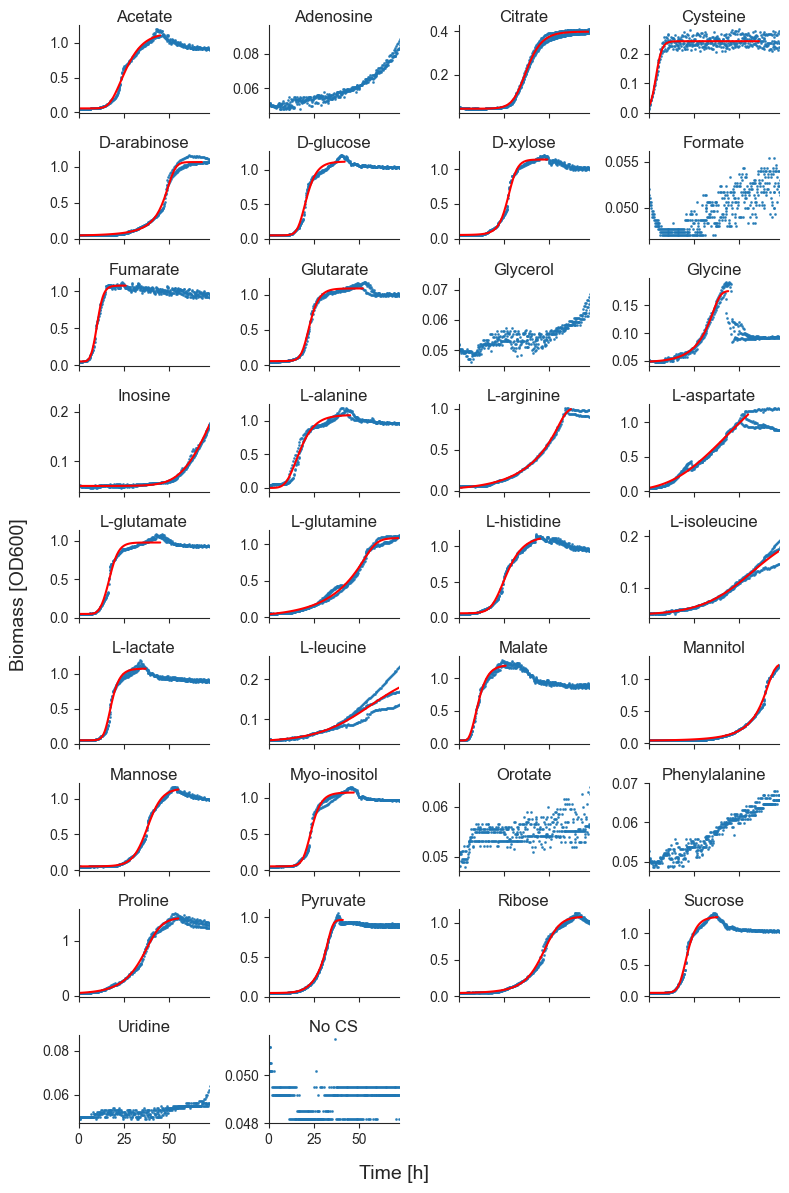

In [35]:
time_buffer = 2
min_max_time = 10
list_of_dicts = []
# models = [curveball.baranyi_roberts_model.BaranyiRoberts, 
#           curveball.baranyi_roberts_model.Richards]
for s in species:
    fig, axes = plt.subplots(9, 4, sharex = True, figsize = (8, 12))
    # for i in range(8):
    #     axes[i, 0].set_ylabel('Biomass [OD600]')
        
    # for i in range(4):
    #     axes[-1, i].set_xlabel('Time [h]')
        
    sns.despine(fig)
    axes = axes.flatten()
    for i, cs in enumerate(cs_list):
        # print(s, cs)
        ax = axes[i]
        idx = (df.Species == s) & (df['Carbon source']==cs)
        dfi = df.loc[idx,:]
        ax.scatter(dfi['Time'], dfi['OD'], s = 1, alpha = 0.8)
        
        if binary_growth_dict[s][cs]:
            peak_time = np.ceil(dfi.loc[dfi.Time>min_max_time, ['Time','OD']].groupby('Time').mean().idxmax().values[0])
            # max_time = np.ceil(dfi['Time'].max())
            print(s, cs, peak_time)
            dfit = dfi.loc[dfi['Time']<=peak_time+time_buffer,:]
            model_fit = curveball.models.fit_model(dfit, PRINT=False, PLOT = False, models = None)
            # print(curveball.models.find_max_growth(model_fits[0])[-1])
            # Use baranyi roberts for growth rate
            # model_idx = np.where([x.model.name=='Model(BaranyiRoberts)' for x in model_fit])[0][0]
            model_idx = 0
            t = np.linspace(0, model_fit[model_idx].userkws['t'].max())
            y_pred = model_fit[model_idx].model.eval(t=t, params=model_fit[model_idx].params)
            
            ax.plot(t,y_pred, c = 'r')
            # Store results 
            dic = store_results(s, cs, model_fit, bri_idx)
            dic['Binary growth evaluation'] = 1
        else:
            dic = store_results(s, cs, None)
            dic['Binary growth evaluation'] = 0
        mean_od = dfi[['Time','OD']].groupby('Time').mean()
        dic['Yield'] = (mean_od.max()-mean_od.iloc[0]).values[0]
        
        list_of_dicts.append(dic)    
        ax.set_title(cs, pad = -50)
        ax.set_xlim(0, 72)
    for i in range(i+1, 9*4):
        axes[i].axis('off')
    fig.supylabel('Biomass [OD600]', size = 14)
    fig.supxlabel('Time [h]', size = 14)
    plt.tight_layout()
    plt.savefig(f'../../supplementary_figures/fitted_growth_curves_{s}.pdf')



In [36]:
res_df = pd.DataFrame(list_of_dicts)

In [37]:
res_df.to_csv(folder / 'fitted_growth_parameters.csv')

In [ ]:
res_df

,Species,Carbon source,model,RSS,RMSD,bic,aic,weighted_bic,weighted_aic,y0,...,nu,q0,v,has_lag,has_nu,max_growth_rate,min_doubling_time,lag,Binary growth evaluation,Yield
0,At,Acetate,Model(BaranyiRoberts),0.322344,0.027704,-2976.162049,-3000.403578,0.945639,0.992433,0.051560,...,0.100000,0.051723,0.167621,True,True,0.095601,7.355898,20.276651,1,0.943733
1,At,Adenosine,Model(LogisticLag2),0.006108,0.003672,-5049.413282,-5069.992743,0.835421,0.537885,0.050398,...,1.000000,0.033609,0.405264,True,False,0.013571,58.409173,14.478554,1,0.061100
2,At,Citrate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.013467
3,At,Cysteine,Model(Logistic),0.697347,0.058467,-1142.478408,-1152.432768,0.930305,0.665241,0.012424,...,1.000000,0.000000,0.000000,False,False,0.769567,0.850503,1.823588,1,0.510567
4,At,D-arabinose,Model(BaranyiRoberts),0.502418,0.039379,-2061.293329,-2083.977790,0.920329,0.996867,0.050640,...,0.567756,0.000100,1.019899,True,True,0.144965,4.485333,16.196469,1,1.265300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,Oa,Pyruvate,Model(BaranyiRoberts),0.089217,0.015549,-3037.373959,-3060.838739,0.985932,0.997985,0.047407,...,5.603800,0.007689,0.310484,True,True,0.156409,4.467260,25.623136,1,0.970033
132,Oa,Ribose,Model(BaranyiRoberts),0.271740,0.025808,-2948.116777,-2972.184380,0.591154,0.914852,0.046243,...,1.413311,0.042025,0.092134,True,True,0.103032,6.805417,35.932425,1,1.065000
133,Oa,Sucrose,Model(BaranyiRoberts),0.321803,0.037569,-1463.825028,-1484.401101,0.999714,0.999948,0.050782,...,0.100000,0.000100,0.595485,True,True,0.356051,1.977255,16.273627,1,1.257667
134,Oa,Uridine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.016667
